In [1]:
import sys
sys.path.append('../')
from pprint import pprint

# Basic Concepts

## Defining equilibrium system

In [2]:
from eq_solver.system import Species, Component, Equilibrium, System, Phase, Constraint

In [3]:
# define all the chemical species except solvent (H2O)
H = Species(name='H+', phase=Phase.LIQUID)
OH = Species(name='OH-', phase=Phase.LIQUID)
Na = Species(name='Na+', phase=Phase.LIQUID)
CO2aq = Species(name='CO2aq', phase=Phase.LIQUID)
HCO3 = Species(name='HCO3-', phase=Phase.LIQUID)
CO3 = Species(name='CO3^2-', phase=Phase.LIQUID)

In [4]:
# component represents an independent "element" with specific constraint conditions

# c(Na) = [Na+] => DIRECT constraint
sodium = Component(name='sodium', constraint=Constraint.DIRECT, base_species=Na, base_charge=+1)

# c(total C) = [CO2aq] + [HCO3-] + [CO3^2-] => TOTAL constraint
# base_species can either be CO3, HCO3, or CO2aq.
carbonate = Component(name='carbonate', constraint=Constraint.TOTAL, base_species=CO3, base_charge=-2)

# [H+] is determined via charge neutrality. => CHARGE constraint
proton = Component(name='proton', constraint=Constraint.CHARGE, base_species=H, base_charge=+1)

# no need to add Component("hydroxide") because a(OH-) can be calculated from a(H+).

In [5]:
# equilibrium
eq_Kw = Equilibrium('Kw', stoichiometry={H: 1, OH: 1}, logK=-14.0)
eq_Ka1 = Equilibrium('Ka1', stoichiometry={HCO3: 1, H: 1, CO2aq: -1}, logK=-6.35)
eq_Ka2 = Equilibrium('Ka2', stoichiometry={CO3: 1, H: 1, HCO3: -1}, logK=-10.33)

In [6]:
# Number of species = 6
# Number of components = 3
# Number of equilibria = 3
# 6 = 3 + 3 holds, meaning that the system is well-defined.

# define equilibrium system
s = System(
    activity_model='none',
    species=(H, OH, Na, CO2aq, HCO3, CO3),
    components=(sodium, carbonate, proton),
    equilibria=(eq_Kw, eq_Ka1, eq_Ka2),
)
# show info on function for optimization
pprint(s.specs)

SystemSpecs(n_vars=2,
            n_loga=2,
            n_solid=0,
            n_ionic_strength=0,
            arguments=('Log a(CO3^2-)', 'Log a(H+)'),
            returns=('Conservation of component "carbonate"',
                     'Charge neutrality'))


## Solving equilibrium

In [7]:
from eq_solver.solver import Conditions, FitFunc

In [8]:
# calculate pH of 0.01 mol/L NaHCO3.
cond = Conditions.from_dict(s, conditions={'carbonate': 0.01, 'sodium': 0.01})
f = FitFunc(s, cond)
res = f.solve()

print(f'pH = {res.pH():.2f}')
for spc, amount in res.distribution('carbonate', relative=True).items():
    print(f'{spc.name}: {amount:.2f}.%')


pH = 8.34
CO2aq: 1.01.%
HCO3-: 97.99.%
CO3^2-: 0.99.%


In [9]:
# calculate pH of 0.01 mol/L Na2CO3.
cond = Conditions.from_dict(s, conditions={'carbonate': 0.01, 'sodium': 0.01*2})
f = FitFunc(s, cond)
res = f.solve()

print(f'pH = {res.pH():.2f}')
for spc, amount in res.distribution('carbonate', relative=True).items():
    print(f'{spc.name}: {amount:.2f}.%')

pH = 11.13
CO2aq: 0.00.%
HCO3-: 13.59.%
CO3^2-: 86.41.%


In [10]:
# calculate pH of 0.01 mol/L CO2(aq).
cond = Conditions.from_dict(s, conditions={'carbonate': 0.01, 'sodium': 0.0})
f = FitFunc(s, cond)
res = f.solve()

print(f'pH = {res.pH():.2f}')
for spc, amount in res.distribution('carbonate', relative=True).items():
    print(f'{spc.name}: {amount:.2f}.%')

pH = 4.18
CO2aq: 99.33.%
HCO3-: 0.67.%
CO3^2-: 0.00.%


## Considering activity coefficients

In [11]:
# eq_solver supports four activity models:
#   "debye_huckel", "ex_debye_huckel", "davies", "truesdell_jones"
# Of these, "davies" model is easier to use since it does not require species-specific parameters.

from dataclasses import replace
s_davies = replace(s, activity_model='davies')
# or
# s_davies = System(
#     activity_model='davies',
#     species=(H, OH, Na, CO2aq, HCO3, CO3),
#     components=(sodium, carbonate, proton),
#     equilibria=(eq_Kw, eq_Ka1, eq_Ka2),
# )

# 0.01 mol/L Na2CO3
cond = Conditions.from_dict(s_davies, conditions={'carbonate': 0.01, 'sodium': 0.01*2})
f = FitFunc(s_davies, cond)
res = f.solve()

# w/o considering activity, pH was 11.13.
print(f'pH = {res.pH():.2f}')
for spc, amount in res.distribution('carbonate', relative=True).items():
    print(f'{spc.name}: {amount:.2f}.%')

pH = 11.00
CO2aq: 0.00.%
HCO3-: 11.71.%
CO3^2-: 88.29.%


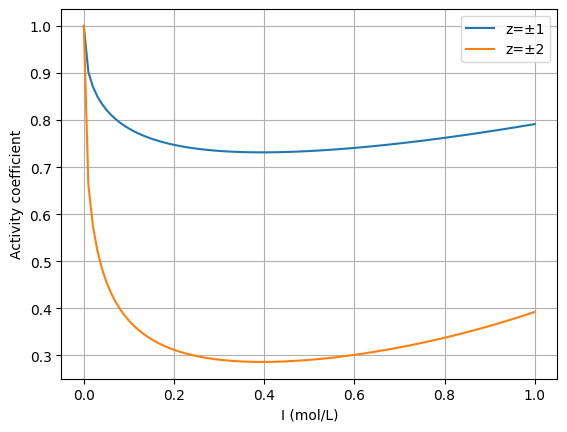

In [12]:
# plot γ(I)
import numpy as np
import matplotlib.pyplot as plt
from eq_solver import activity_models as am
I = np.linspace(0, 1.0, 100)

plt.figure()
plt.plot(I, am.davies(I, z=1, temp=298.15), label='z=±1')
plt.plot(I, am.davies(I, z=2, temp=298.15), label='z=±2')
plt.xlabel('I (mol/L)')
plt.ylabel('Activity coefficient')
plt.legend()
plt.grid()